# PCA (Principal Component Analysis)

In [6]:
import pandas as pd

# Load the Wine dataset
df_wine = pd.read_csv('https://gist.githubusercontent.com/tijptjik/9408623/raw/b237fa5848349a14a14e5d4107dc7897c21951f5/wine.csv')

# Show a data sample
print(f"Sample:\n", df_wine.sample(10))

# Show some general statistics
print(f"\n\nDescription:\n", df_wine.describe())

Sample:
      Wine  Alcohol  Malic.acid   Ash   Acl   Mg  Phenols  Flavanoids  \
168     3    13.58        2.58  2.69  24.5  105     1.55        0.84   
149     3    13.08        3.90  2.36  21.5  113     1.41        1.39   
148     3    13.32        3.24  2.38  21.5   92     1.93        0.76   
174     3    13.40        3.91  2.48  23.0  102     1.80        0.75   
91      2    12.00        1.51  2.42  22.0   86     1.45        1.25   
34      1    13.51        1.80  2.65  19.0  110     2.35        2.53   
66      2    13.11        1.01  1.70  15.0   78     2.98        3.18   
73      2    12.99        1.67  2.60  30.0  139     3.30        2.89   
31      1    13.58        1.66  2.36  19.1  106     2.86        3.19   
97      2    12.29        1.41  1.98  16.0   85     2.55        2.50   

     Nonflavanoid.phenols  Proanth  Color.int   Hue    OD  Proline  
168                  0.39     1.54       8.66  0.74  1.80      750  
149                  0.34     1.14       9.40  0.57  1.33   

Steps: 
1. **Data standarization:** all the variables will have a mean 0 and std = 1 to prevent variables to dominate others just bc they have bigger values
2. **Calculate the covariance matrixes:** this tells us how variables are correlated (ej: if alcohol and color have positive covariance, when one increases, the other will also increase)
3. **Find the eigenvalues and eigenvectors:** 
    - The eigenvalues indicate how much information (variance) each principal component carries. 
    - The eigenvectors give you the direction of these components.
4. **Order and select the best components:** You typically choose the first 2 or 3, which explain most of the variance. This allows you to visualize data that was in 13 dimensions in just 2D.

**Data standardization**

In [7]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Split the dataset into features (X) and target labels (y).
# y: The first column (Wine) contains wine class types labels (1, 2, 3).
# X: All other columns (Alcohol, Malic.acid, etc.) are features for PCA
# * Why this? PCA is applied to features, not the target variable. This ensures we reduce the dimensionality of the input data, not the labels.
X = df_wine.iloc[:, 1:].values  # All columns except "Wine" (13 features)
y = df_wine.iloc[:, 0].values   # "Wine" column (class labels 1, 2, 3)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

# Standardize features (critical for PCA)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

**Perform PCA**

In [8]:
from sklearn.decomposition import PCA

# Perform PCA 
pca = PCA()
X_pca = pca.fit_transform(X_std)

**Compute the eigenvalues and eigenvectors**

In [16]:
# 1. Eigenvalues (Explained Variance)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 2. Loadings (Component Coefficients)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Print results
print("Explained Variance Ratios:", explained_variance)
print("Cumulative Variance:", cumulative_variance)
print("\nLoadings (PC1 and PC2):")
for i, feature in enumerate(df_wine.columns[1:]):
    print(f"{feature}: PC1={loadings[i, 0]:.2f}, PC2={loadings[i, 1]:.2f}")

Explained Variance Ratios: [0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]
Cumulative Variance: [0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]

Loadings (PC1 and PC2):
Alcohol: PC1=0.31, PC2=0.77
Malic.acid: PC1=-0.53, PC2=0.36
Ash: PC1=-0.00, PC2=0.50
Acl: PC1=-0.52, PC2=-0.02
Mg: PC1=0.31, PC2=0.47
Phenols: PC1=0.86, PC2=0.10
Flavanoids: PC1=0.92, PC2=-0.01
Nonflavanoid.phenols: PC1=-0.65, PC2=0.05
Proanth: PC1=0.68, PC2=0.06
Color.int: PC1=-0.19, PC2=0.84
Hue: PC1=0.65, PC2=-0.44
OD: PC1=0.82, PC2=-0.26
Proline: PC1=0.62, PC2=0.58


**# Visualization of the variance**

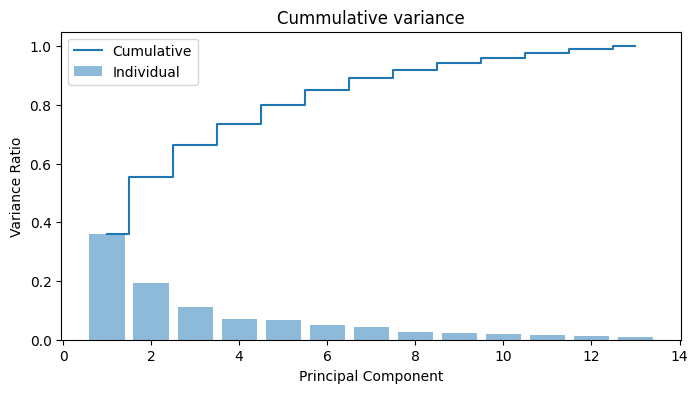

In [22]:
import matplotlib.pyplot as plt

# Variance plot
plt.figure(figsize=(8, 4))
plt.bar(range(1, 14), explained_variance, alpha=0.5, align='center', label='Individual')
plt.step(range(1, 14), cumulative_variance, where='mid', label='Cumulative')
plt.ylabel('Variance Ratio')
plt.xlabel('Principal Component')
plt.legend()
plt.title("Cummulative variance")
plt.show()

☝️ Interpretation of the chart above: we can see that the 3 first components represent about 80% of the variance. This means we can represent the data in just that number of dimensions without loosing too much information. The line represents the cummulative variance.

\* *In case we needed 5 or 6 components to reach that 80%, is probably not worth it using this reduction system*

**Visualization**

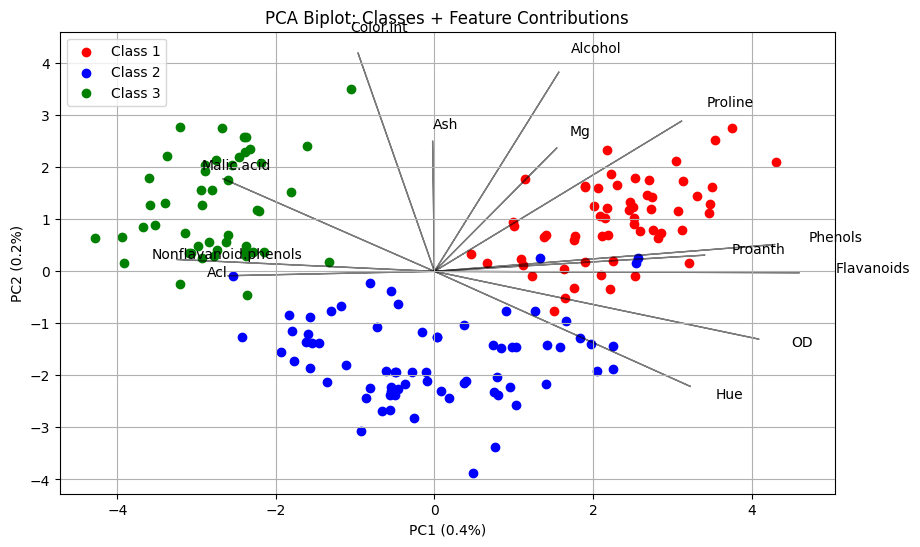

In [ ]:
# Biplot (Features + Samples)
plt.figure(figsize=(10, 6))
for l, c in zip(np.unique(y), ('r', 'b', 'g')):
    plt.scatter(X_pca[y == l, 0], X_pca[y == l, 1], c=c, label=f'Class {l}')
    
# Add feature vectors
for i, feature in enumerate(df_wine.columns[1:]):
    plt.arrow(0, 0, loadings[i, 0]*5, loadings[i, 1]*5, color='k', alpha=0.5)
    plt.text(loadings[i, 0]*5.5, loadings[i, 1]*5.5, feature, color='k')
plt.xlabel('PC1 ({}%)'.format(round(explained_variance[0], 1)))
plt.ylabel('PC2 ({}%)'.format(round(explained_variance[1], 1)))
plt.title("PCA Biplot: Classes + Feature Contributions")
plt.legend()
plt.grid()
plt.show()

☝️ Interpretation of the chart above: 
- The 3 colors correspond to wine classes (1-red, 2-blue, 3-green) from the original "Wine" column
- This shows how well the PCA-separated the different wine types in 2D space
- We observe that original features strongly correlate with class differences.